1. Пусть Xi ∼ Bern(θ), для H0 : θ = 1/2 и H1 : θ = θ1, где а) θ1 = 1/3, б) θ1 = 2/3. Рассмотрим критерий {sum Xi > C}, n = 10. Построить графики вероятностей ошибки I рода, ошибки II рода и
мощности критерия в зависимости от C. Для какой из двух альтернатив осмысленно использовать
этот критерий?

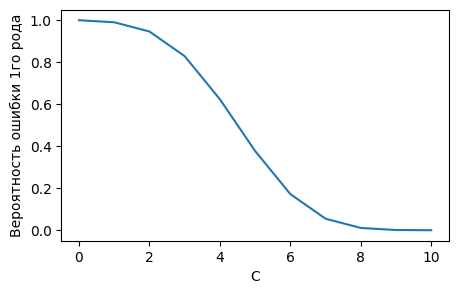

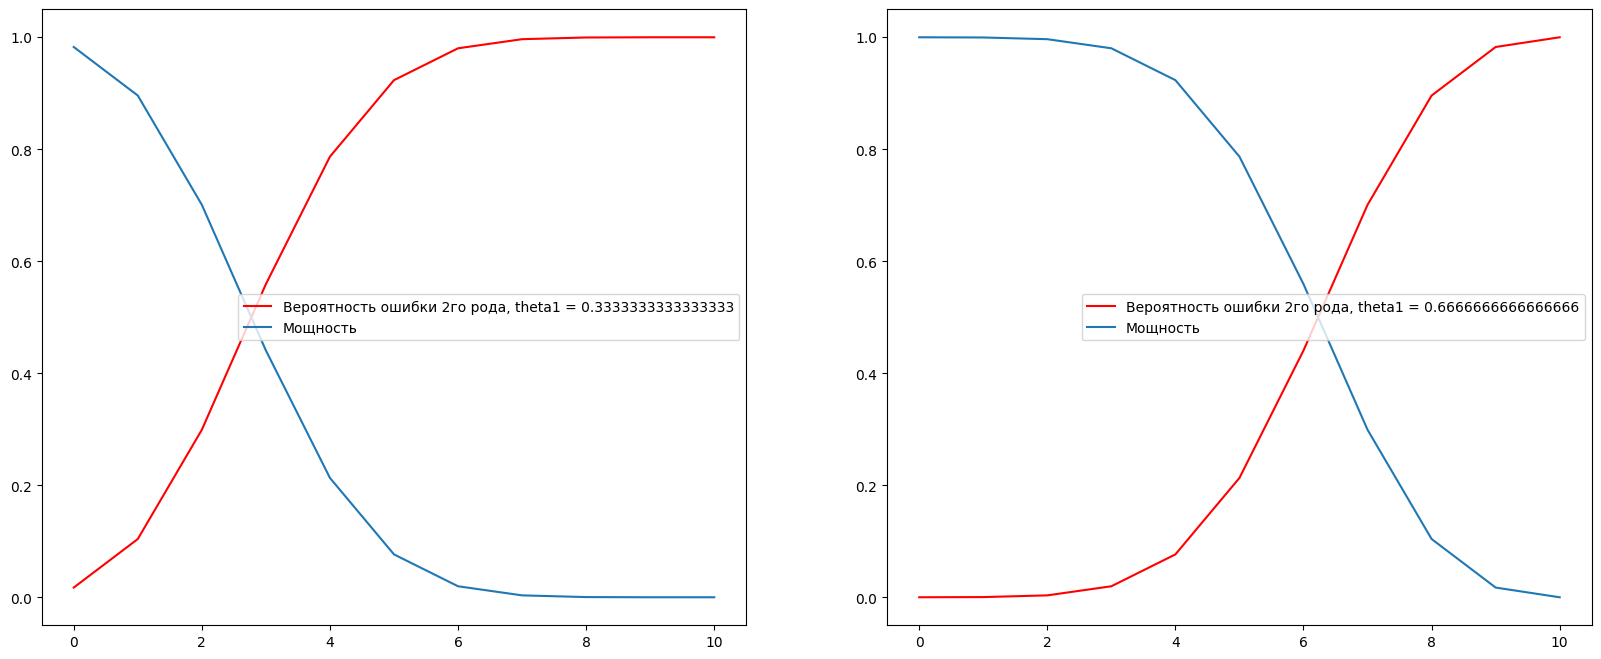

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
#sample = np.random.binomial(1, theta_true, n), sum(sample) имеет распределение binomial(n, theta_true)

def bild_test(theta1_values, C_values):
    Y_H0 = stats.binom(n, 1/2) #D = {Y>C}
    type_1_error_probabilitys = []
    for C in C_values:
    #Вероятность ошибки 1го рода(отвергнуть H0 при условии, что она верна), т.е. P(D) при H0
        type_1_error_probability = 1 - Y_H0.cdf(C)
        type_1_error_probabilitys.append(type_1_error_probability)
    plt.figure(figsize=(5, 3))
    plt.plot(C_values, type_1_error_probabilitys)
    plt.xlabel('C')
    plt.ylabel('Вероятность ошибки 1го рода')
    plt.show()

    plt.figure(figsize=(20, 8))
    for idx, theta1 in enumerate(theta1_values):
        type_2_error_probabilitys = []
        powers_of_test = []
        for C in C_values:
            #Вероятность ошибки 2го рода(принять H0 при условии, что верна H1), т.е. P(не D) при H1
            Y_H1 = stats.binom(n, theta1)
            type_2_error_probability = Y_H1.cdf(C)
            type_2_error_probabilitys.append(type_2_error_probability)
            power_of_test = 1 - type_2_error_probability
            powers_of_test.append(power_of_test)
        
        plt.subplot(1, 2, idx + 1)
        plt.plot(C_values, type_2_error_probabilitys, color = 'red', label = f'Вероятность ошибки 2го рода, theta1 = {theta1_values[idx]}')
        plt.plot(C_values, powers_of_test, label = 'Мощность')
        plt.legend()
    plt.show()

theta1_values = [1/3, 2/3]
C_values = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
n = 10
bild_test(theta1_values, C_values)
#как мы понимаем, какой критерий лучше? изначально хочу минимизировать ошибку 1го рода, например, пусть 0,2 -> С=6 -> смотрим на график мощности, где она больше? этот критерий лучше

2. График ЭФР p-value.
(a) Находим функцию распределения FT (x) нашей статистики при H0 (всегда при H0, даже если
выборка будет соответствовать альтернативе!).
(b) Генерируем выборку, находим значение статистики критерия T. Вычисляем p − value = 1 −
FT (T) для критических множеств вида {T > C}, p−value = FT (T) для критических множеств
вида {T < C}. Повторяем m ≥ 100 раз. Получился массив p1, . . . , pm, упорядочиваем его по
возрастанию.
(c) Строим график: по оси Ox – значения p1, . . . , pm, по оси Oy – числа 1/m, 2/m, . . . , 1. Иными
словами, мы строим график эмпирической функции распределения p-value.
Можно воспользоваться встроенной функцией ecdf (там же есть пример построения графика),
тогда массив p-value не обязательно упорядочивать.
Мы знаем, что если F(x) непрерывна, то FT (T) ∼ R[0, 1]. Значит, при гипотезе точки должны
быть близки к прямой y = x. При альтернативе мы ожидаем увидеть отклонение от этой прямой.
На график ЭФР p-value можно также смотреть как на график мощности критерия от вероятности
ошибки I рода.
Посмотрим как это работает на синтетическом наборе данных:
пусть Xi ∼ N (θ, 1),

H0 : θ = 0,
H1 : θ = θ1. Постройте а) критерий Неймана-Пирсона для θ1 > 0 б) для θ1 < 0 в) асимптотиче-
ский критерий |MED − x1/2| > C. Рассчитайте для них ф.р. статистик критерия, найдите p-value
критериев.
(a) Построить графики p-value всех трех критериев, выбирая данные а) при верной нулевой
гипотезе б) при каждой из альтернатив (θ1 = −1 и θ1 = 1). Построить их на одном графике.
В какую сторону отклоняются графики от прямой y = x?
(b) Как влияет размер выборки на отклонение от y = x?
(c) Какой критерий самый лучший?

![cv](median.png)

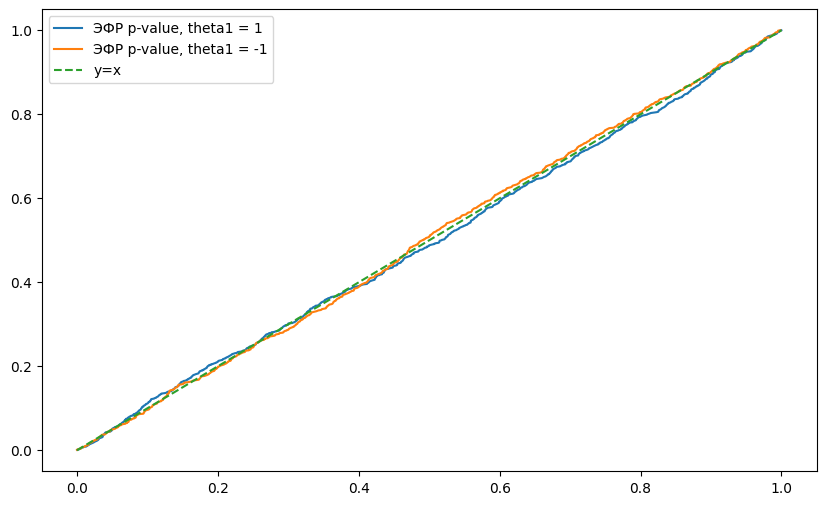

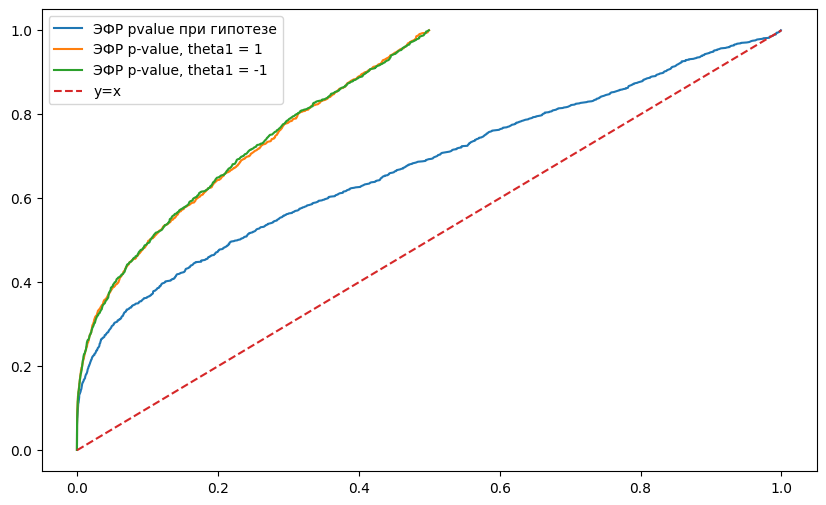

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import norm
from statsmodels.distributions.empirical_distribution import ECDF

n = 50
m = 1000       
theta0 = 0     
theta1_values = [1, -1] 
N_sim = 1000

def bild_Neyman_Pearson_test(theta_true, theta1, N_sim, n):
    T_dist = norm(0, 1 / np.sqrt(n))# T ~ N(0, 1/n) при H0
    pvalues = []
    for _ in range(N_sim):
        sample = np.random.normal(theta_true, 1, n)
        T = np.mean(sample)  #статистика критерия, сам критерий D = {T * θ1 > ln(C) + n * (θ1**2) / 2}  ->   знак зависит от знака θ1
        if theta1 < 0:
            pvalue = T_dist.cdf(T)
        else:
            pvalue = 1 - T_dist.cdf(T)
        pvalues.append(pvalue)
    pvalue_ecdf = ECDF(pvalues)
    plt.plot(pvalue_ecdf.x, pvalue_ecdf.y, label = f'ЭФР p-value, theta1 = {theta1_values[0] if theta1 == 1 else theta1_values[1]}')
    plt.legend()
    
def asymp_test_med(theta1_values, N_sim, n):  
    p_values_H0 = []
    sigma = np.sqrt(np.pi / (2 * n))
    for _ in range(N_sim):
        sample = np.random.normal(0, 1, n) #H0
        med = np.median(sample)
        half = np.sum(np.max(sample) + np.min(sample)) / 2
        T = np.abs(med - half)
        z = abs(T) / sigma
        p_value = 2 * (1 - stats.norm.cdf(z))
        p_values_H0.append(p_value)
    pvalue_ecdf = ECDF(p_values_H0)
    plt.plot(pvalue_ecdf.x, pvalue_ecdf.y, label = 'ЭФР pvalue при гипотезе')
    plt.legend()
    for theta1 in theta1_values:
        p_values = []
        for _ in range(N_sim):
            sample = np.random.normal(theta1, 1, n) #H1
            med = np.median(sample)
            half = np.sum(np.max(sample) + np.min(sample)) / 2
            T = np.abs(med - half)
            z = T / sigma
            p_value = 1 - stats.norm.cdf(z)
            p_values.append(p_value)
        pvalue_ecdf = ECDF(p_values)
        plt.plot(pvalue_ecdf.x, pvalue_ecdf.y, label = f'ЭФР p-value, theta1 = {theta1_values[0] if theta1 == 1 else theta1_values[1]}')
        plt.legend()
    
 
plt.figure(figsize=(10, 6))   
bild_Neyman_Pearson_test(0, 1, N_sim, n)
bild_Neyman_Pearson_test(0, -1, N_sim, n)
plt.plot([0,1], [0,1], '--', label = 'y=x')
plt.legend()
plt.figure(figsize=(10, 6)) 
asymp_test_med(theta1_values, N_sim, n)
plt.plot([0,1], [0,1], '--', label = 'y=x')
plt.legend()

3. X1, . . . , Xn ∼ Bern(θ), H0 : θ = 1/2, H1 : θ = 1/3. При каких n можно построить критическое множество вида {sum(Xi) < C} так, чтобы вероятности ошибок первого и второго рода не превышали
0.05? Построить графики вероятностей ошибок первого и второго рода (как функции от C) для
разных n.

Размер выборки 98


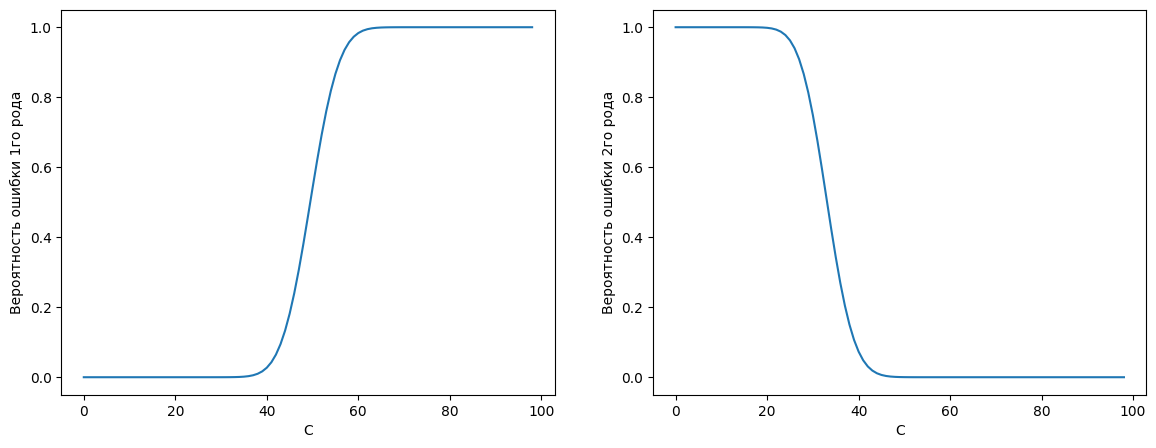

Размер выборки 110


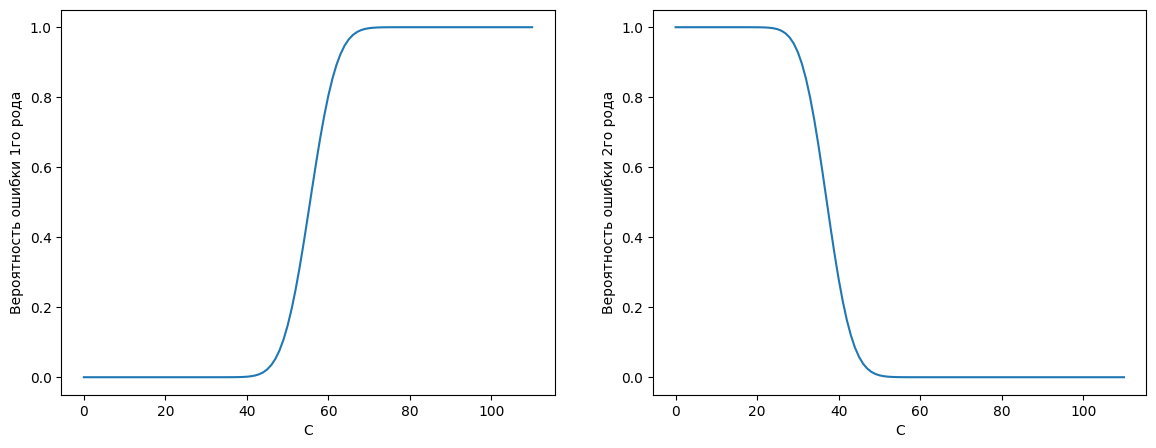

Размер выборки 120


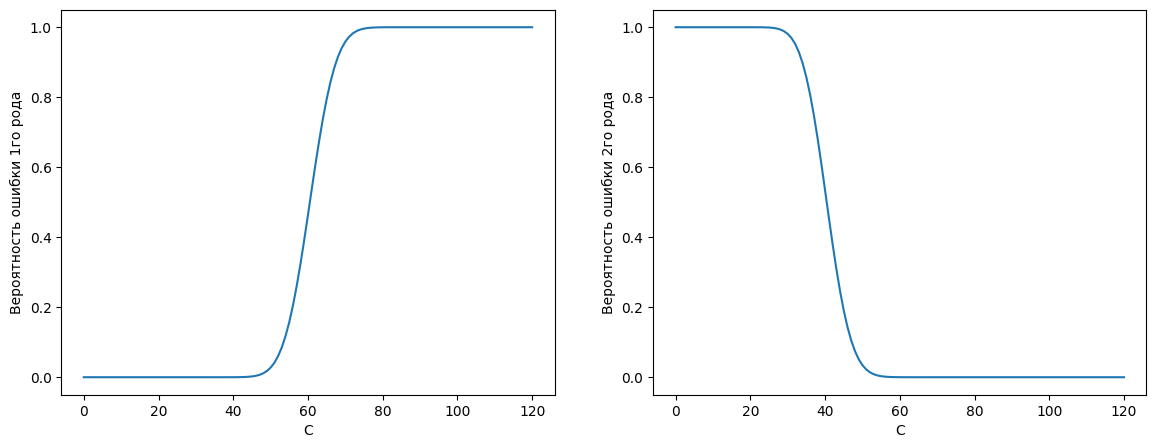

Размер выборки 150


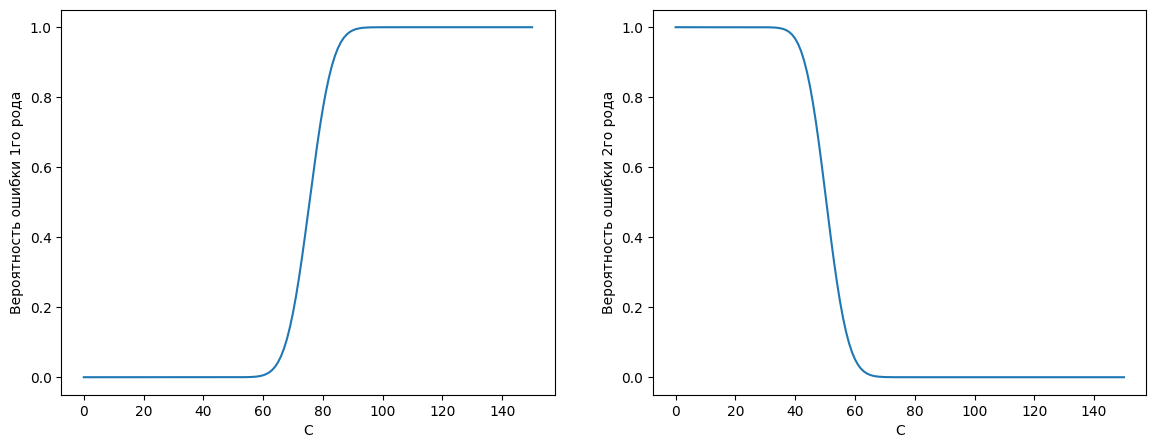

In [25]:
def define_sample_size(theta0, theta1, alpha, n_values):
    n_values_good = []
    for n in n_values:
        for C in range(n+1):
            Y_0 = stats.binom(n, theta0)
            Y_1 = stats.binom(n, theta1)
            type_1_error_probability = Y_0.cdf(C - 1) if C > 0 else 0
            type_2_error_probability = 1 - Y_1.cdf(C - 1) if C > 0 else 1
            if type_1_error_probability <= alpha and type_2_error_probability <= alpha:
                n_values_good.append(n)
                break
    return n_values_good
            
n_values = list(range(151))            
theta0 = 1/2
theta1 = 1/3
alpha = 0.05
n_val_good = define_sample_size(theta0, theta1, alpha, n_values)
n_plot = [np.min(n_val_good), n_val_good[10], n_val_good[20], np.max(n_val_good)]

for n in n_plot:
    Y_0 = stats.binom(n, theta0)
    Y_1 = stats.binom(n, theta1)
    C_values = range(n+1)
    type1_errors = []
    type2_errors = []
    for C in C_values:
        type_1_error_probability = Y_0.cdf(C - 1) if C > 0 else 0
        type_2_error_probability = 1 - Y_1.cdf(C - 1) if C > 0 else 1       
        type1_errors.append(type_1_error_probability)
        type2_errors.append(type_2_error_probability)
    print(f"Размер выборки {n}")    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    ax1.plot(C_values, type1_errors)
    ax1.set_xlabel('C')
    ax1.set_ylabel('Вероятность ошибки 1го рода')
    
    ax2.plot(C_values, type2_errors)
    ax2.set_xlabel('C')
    ax2.set_ylabel('Вероятность ошибки 2го рода')
    plt.show()
